In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
import pandas as pd

params = {'figure.figsize': (10, 10*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)

In [2]:
#df = pd.read_hdf('../../dataset_complete/BDT/BDT_all_updated.h5', key='data')
df = pd.read_hdf('../../dataset_complete/BDT/BDT_all_updated_with_muon.h5', key='data')

In [3]:
boolCC = (df.Label == 1) #& (df.RecoEnergy >= 3) & (df.RecoEnergy <= 15) & (df.RecoZenith <= -0.3)
boolNC = (df.Label == 2) #& (df.RecoEnergy >= 3) & (df.RecoEnergy <= 15) & (df.RecoZenith <= -0.3)
boolMUON = (df.Label == 2)
#boolNC = (df.Label == 2) #& (df.TrueEnergy >= 2) & (df.TrueEnergy <= 15) & (df.TrueZenith <= -0.3)

In [4]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 10
    else:
        max_val = 30 #charge
    
    for i in range(0, max_val):#range(0, len(charge_val)-1):#
        qmin= i*10 #charge_val[i]#
        qmax= (i+1)*10 #charge_val[i+1]#
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len( xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-0.5) #append(qmax - 5)

    return sep_var, p_val, bin_centers

In [5]:
def get_statistic(xCC, xNC, diff_varCC, diff_varNC, energy=True):
    sep_var = []
    p_val = []
    bin_centers = []

    #charge_val = [10, 50, 100, 150, 200, 250]

    if energy:
        max_val = 2 #np.log10(100)
    else:
        max_val = 2.5 #np.log10(100) #charge

    steps = np.arange(0, max_val, 0.1)

    #print(steps)

    diff_varCC = np.log10(diff_varCC)
    diff_varNC = np.log10(diff_varNC)
        
    for i in steps:#range(0, len(charge_val)-1):#
        
        qmin= i #charge_val[i]#
        qmax= i+0.1 #charge_val[i+1]#

        #print(qmin, qmax)
        
        maskCC = (diff_varCC>=qmin)&(diff_varCC<=qmax)
        maskNC = (diff_varNC>=qmin)&(diff_varNC<=qmax)
        
        if len(xCC[maskCC]) != 0 and len(xNC[maskNC]) != 0:
            
            ks_statistic, pvalue = ks_2samp(xCC[maskCC], xNC[maskNC])
            
            sep_var.append(ks_statistic)
            p_val.append(pvalue)
            bin_centers.append(qmax-(0.1/2)) #append(qmax - 5)

            #plt.hist(xCC[maskCC], bins=100, histtype='step', log=True, density=True, label='CC', lw=2)
            #plt.hist(xNC[maskNC], bins=100, histtype='step', log=True, density=True, label='NC', lw=2)
            #plt.title(np.round(ks_statistic, 3))
            #plt.show()

    return sep_var, p_val, bin_centers

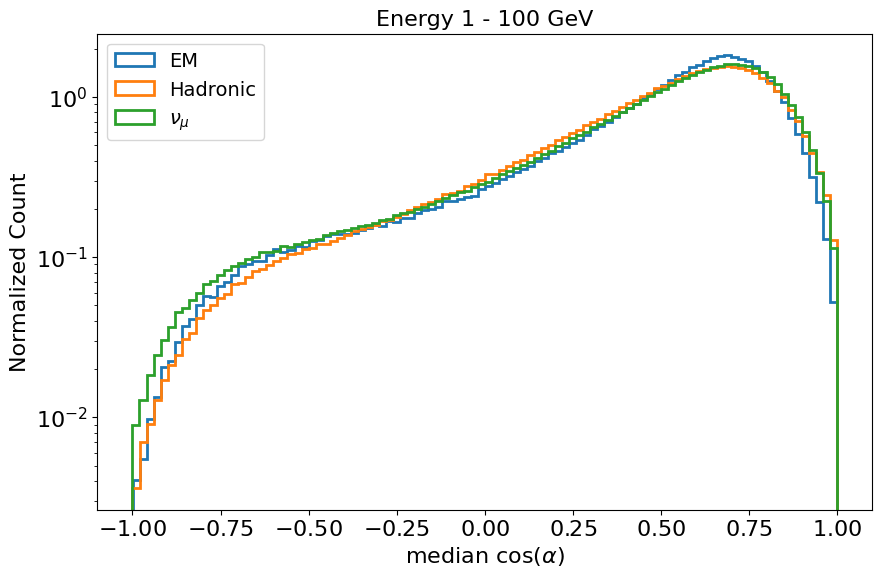

In [5]:
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3,3))

plt.hist(df.ang_median[boolCC], bins=100, histtype='step', log = True, density=True, label='EM', lw=2)
plt.hist(df.ang_median[boolNC], bins=100, histtype='step', log = True, density=True, label='Hadronic', lw=2)
plt.hist(df.ang_median[boolMUON], bins=100, histtype='step', log = True, density=True, label=r'$\nu_\mu$', lw=2)
#plt.axvline(x = 0.5, linestyle='--', c='k')
#plt.axvline(x = 0.9, linestyle='--', c='k')
#plt.hist(df.tres_median[boolMUON], bins=100, histtype='step', log = True, density=True, label='Muon Neutrino', lw=2)
plt.legend()
#plt.xlabel(r'$\beta_{1}$')
plt.xlabel(r'median $\cos(\alpha)$')
plt.ylabel('Normalized Count')
plt.title('Energy {} - {} GeV'.format(1, 100))

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x')  # Optional: for auto-scaling
ax.xaxis.set_major_formatter(formatter)
#plt.savefig('./EM_vs_Hadronic_vs_NuMu_Median_Angle.pdf', bbox_inches='tight', dpi=200)

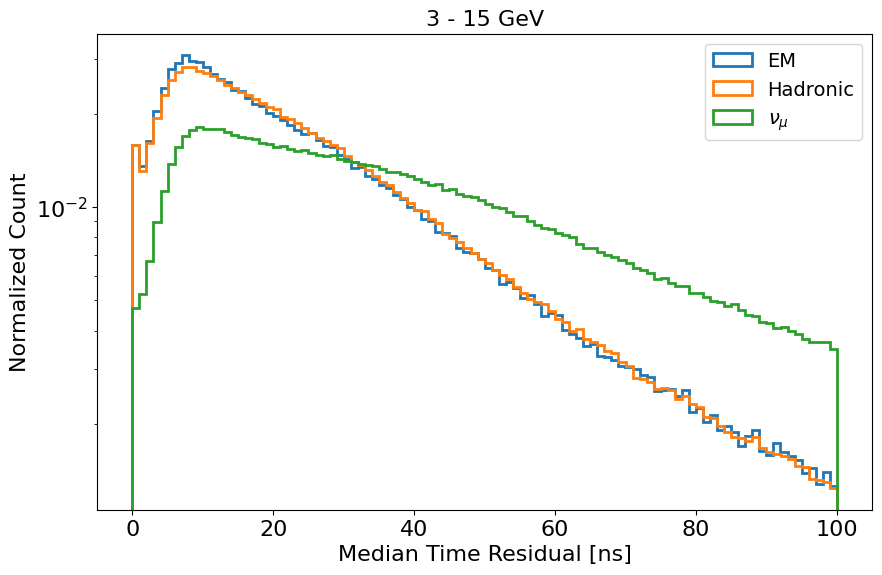

In [19]:
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3,3))

plt.hist(df.tres_median[boolCC][(df.tres_median >= 0)&(df.tres_median <= 100)&(df.RecoEnergy >= 3)&(df.RecoEnergy <= 15)], bins=100, histtype='step', log = True, density=True, label='EM', lw=2)
plt.hist(df.tres_median[boolNC][(df.tres_median >= 0)&(df.tres_median <= 100)&(df.RecoEnergy >= 3)&(df.RecoEnergy <= 15)], bins=100, histtype='step', log = True, density=True, label='Hadronic', lw=2)
plt.hist(df.tres_median[boolMUON][(df.tres_median >= 0)&(df.tres_median <= 100)&(df.RecoEnergy >= 3)&(df.RecoEnergy <= 15)], bins=100, histtype='step', log = True, density=True, label=r'$\nu_\mu$', lw=2)
#plt.axvline(x = 0.5, linestyle='--', c='k')
#plt.axvline(x = 0.9, linestyle='--', c='k')
#plt.hist(df.tres_median[boolMUON], bins=100, histtype='step', log = True, density=True, label='Muon Neutrino', lw=2)
plt.legend()
#plt.xlabel(r'$\beta_{1}$')
plt.xlabel(r'Median Time Residual [ns]')
plt.ylabel('Normalized Count')
plt.title('{} - {} GeV'.format(3, 15))

#ax = plt.gca()
#ax.ticklabel_format(style='scientific', axis='x')  # Optional: for auto-scaling
#ax.xaxis.set_major_formatter(formatter)
plt.savefig('./EM_vs_Hadronic_vs_NuMu_Median_TRes.pdf', bbox_inches='tight', dpi=200)

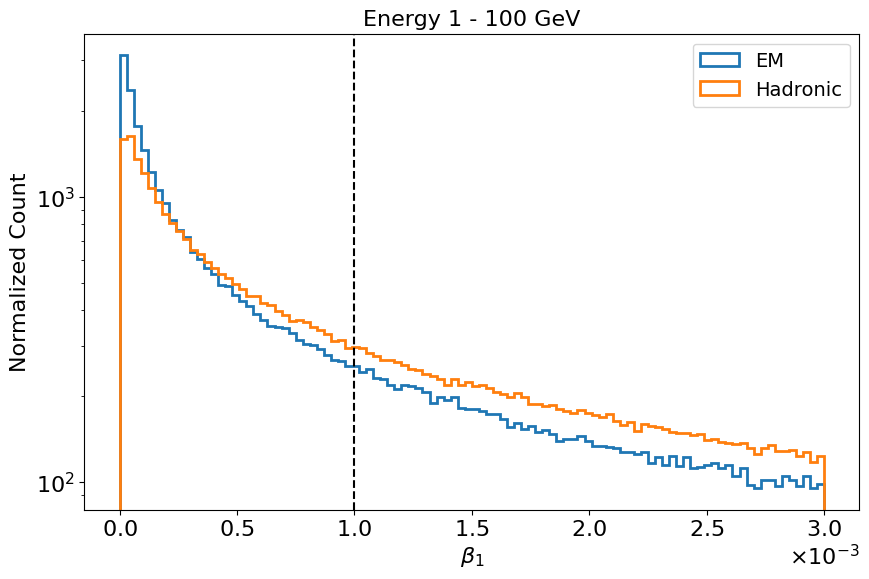

In [17]:
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3,3))

plt.hist(df.Beta1Reco[boolCC][(df.Beta1Reco >= 0)&(df.Beta1Reco <= 0.003)], bins=100, histtype='step', log = True, density=True, label='EM', lw=2)
plt.hist(df.Beta1Reco[boolNC][(df.Beta1Reco >= 0)&(df.Beta1Reco <= 0.003)], bins=100, histtype='step', log = True, density=True, label='Hadronic', lw=2)
plt.axvline(x = 0.001, linestyle='--', c='k')
plt.legend()
plt.xlabel(r'$\beta_{1}$')
plt.ylabel('Normalized Count')
plt.title('Energy {} - {} GeV'.format(1, 100))

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x')  # Optional: for auto-scaling
ax.xaxis.set_major_formatter(formatter)
plt.savefig('./EM_vs_Hadronic_Straight_Cuts_Beta1.pdf', bbox_inches='tight', dpi=200)

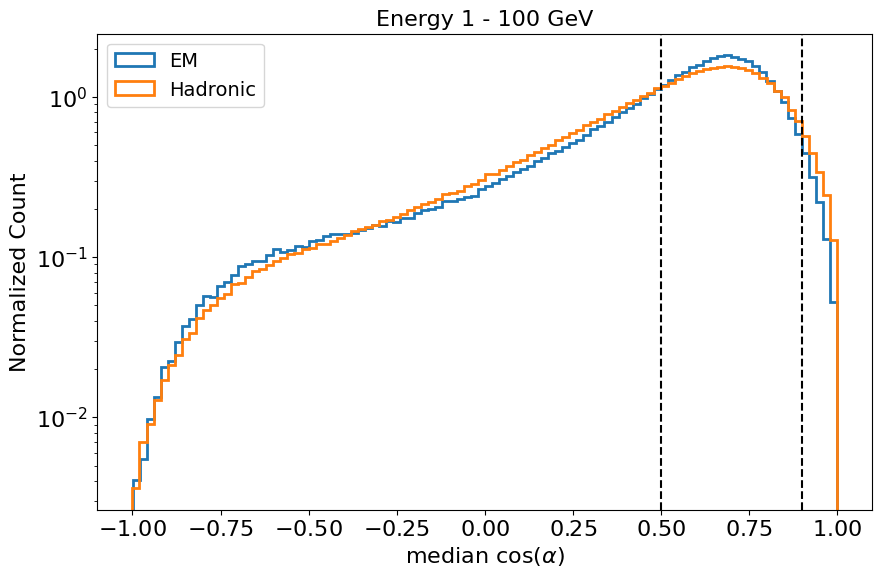

In [19]:
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3,3))

plt.hist(df.ang_median[boolCC], bins=100, histtype='step', log = True, density=True, label='EM', lw=2)
plt.hist(df.ang_median[boolNC], bins=100, histtype='step', log = True, density=True, label='Hadronic', lw=2)
plt.axvline(x = 0.5, linestyle='--', c='k')
plt.axvline(x = 0.9, linestyle='--', c='k')
#plt.hist(df.tres_median[boolMUON], bins=100, histtype='step', log = True, density=True, label='Muon Neutrino', lw=2)
plt.legend()
#plt.xlabel(r'$\beta_{1}$')
plt.xlabel(r'median $\cos(\alpha)$')
plt.ylabel('Normalized Count')
plt.title('Energy {} - {} GeV'.format(1, 100))

ax = plt.gca()
ax.ticklabel_format(style='scientific', axis='x')  # Optional: for auto-scaling
ax.xaxis.set_major_formatter(formatter)
plt.savefig('./EM_vs_Hadronic_Straight_Cuts_Median_Angle.pdf', bbox_inches='tight', dpi=200)

In [6]:
features = ['CogDistance',
 'Beta1Reco',
 'tres_median',
 'tres_iqr',
 'tres_skew',
 'dist_iqr',
 'dist_skew',
 'ang_median',
 'ang_iqr',
 'ang_kurtosis',
 'ang_skew']

# Store results in dictionaries
sep_vars_energy = {}
p_vals_energy = {}
bin_centers_energy = {}

sep_vars_charge = {}
p_vals_charge = {}
bin_centers_charge = {}

for feat in features:
    # With respect to RecoEnergy
    sep_var, p_val, bin_centers = get_statistic(
        df[feat][boolCC], df[feat][boolNC],
        df.RecoEnergy[boolCC], df.RecoEnergy[boolNC]
    )
    sep_vars_energy[feat] = sep_var
    p_vals_energy[feat] = p_val
    bin_centers_energy[feat] = bin_centers

    # With respect to TotalCharge
    sep_var_c, p_val_c, bin_centers_c = get_statistic(
        df[feat][boolCC], df[feat][boolNC],
        df.TotalCharge[boolCC], df.TotalCharge[boolNC],
        energy=False
    )
    sep_vars_charge[feat] = sep_var_c
    p_vals_charge[feat] = p_val_c
    bin_centers_charge[feat] = bin_centers_c

In [7]:

'''
import matplotlib.pyplot as plt

# ---------------- Plot 2: Reco Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].errorbar(bin_centers_energy['tres_median'], sep_vars_energy['tres_median'], yerr=p_vals_energy['tres_median'], fmt='*--', linewidth=2, label='tres median')
axs[0].errorbar(bin_centers_energy['tres_iqr'], sep_vars_energy['tres_iqr'], yerr=p_vals_energy['tres_iqr'], fmt='*--', linewidth=2, label='tres iqr')
axs[0].errorbar(bin_centers_energy['tres_skew'], sep_vars_energy['tres_skew'], yerr=p_vals_energy['tres_skew'], fmt='*--', linewidth=2, label='tres skew')
#axs[0].set_title('OM level features')
axs[0].set_xlabel('Reco Energy [GeV]')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].errorbar(bin_centers_energy['ang_median'], sep_vars_energy['ang_median'], yerr=p_vals_energy['ang_median'], fmt='*--', linewidth=2, label='ang median')
axs[1].errorbar(bin_centers_energy['ang_iqr'], sep_vars_energy['ang_iqr'], yerr=p_vals_energy['ang_iqr'], fmt='*--', linewidth=2, label='ang iqr')
axs[1].errorbar(bin_centers_energy['ang_kurtosis'], sep_vars_energy['ang_kurtosis'], yerr=p_vals_energy['ang_kurtosis'], fmt='*--', linewidth=2, label='ang kurtosis')
axs[1].errorbar(bin_centers_energy['ang_skew'], sep_vars_energy['ang_skew'], yerr=p_vals_energy['ang_skew'], fmt='*--', linewidth=2, label='ang skew')
#axs[1].set_title('Beta Variables')
axs[1].set_xlabel('Reco Energy [GeV]')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].errorbar(bin_centers_energy['dist_iqr'], sep_vars_energy['dist_iqr'], yerr=p_vals_energy['dist_iqr'], fmt='*--', linewidth=2, label='dist iqr')
axs[2].errorbar(bin_centers_energy['dist_skew'], sep_vars_energy['dist_skew'], yerr=p_vals_energy['dist_skew'], fmt='*--', linewidth=2, label='dist skew')
axs[2].errorbar(bin_centers_energy['Beta1Reco'], sep_vars_energy['Beta1Reco'], yerr=p_vals_energy['Beta1Reco'], fmt='*--', linewidth=2, label='Beta1')
axs[2].errorbar(bin_centers_energy['CogDistance'], sep_vars_energy['CogDistance'], yerr=p_vals_energy['CogDistance'], fmt='*--', linewidth=2, label='Cog Distance')
#axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('Reco Energy [GeV]')
axs[2].legend()
axs[2].grid(True)

fig.suptitle(r'EM vs Hadronic Shower', fontsize=16)
#fig.suptitle(r'EM vs $\nu_\mu$', fontsize=16)
plt.tight_layout()
#plt.show()
plt.savefig('./EM_vs_Hadronic_KS_test_statistic.pdf', bbox_inches='tight', dpi=200)
'''

"\nimport matplotlib.pyplot as plt\n\n# ---------------- Plot 2: Reco Energy ----------------\nfig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)\n\n# Geometry\naxs[0].errorbar(bin_centers_energy['tres_median'], sep_vars_energy['tres_median'], yerr=p_vals_energy['tres_median'], fmt='*--', linewidth=2, label='tres median')\naxs[0].errorbar(bin_centers_energy['tres_iqr'], sep_vars_energy['tres_iqr'], yerr=p_vals_energy['tres_iqr'], fmt='*--', linewidth=2, label='tres iqr')\naxs[0].errorbar(bin_centers_energy['tres_skew'], sep_vars_energy['tres_skew'], yerr=p_vals_energy['tres_skew'], fmt='*--', linewidth=2, label='tres skew')\n#axs[0].set_title('OM level features')\naxs[0].set_xlabel('Reco Energy [GeV]')\naxs[0].set_ylabel('KS Test Statistic')\naxs[0].legend()\naxs[0].grid(True)\n\n# Betas\naxs[1].errorbar(bin_centers_energy['ang_median'], sep_vars_energy['ang_median'], yerr=p_vals_energy['ang_median'], fmt='*--', linewidth=2, label='ang median')\naxs[1].errorbar(bin_centers_ene

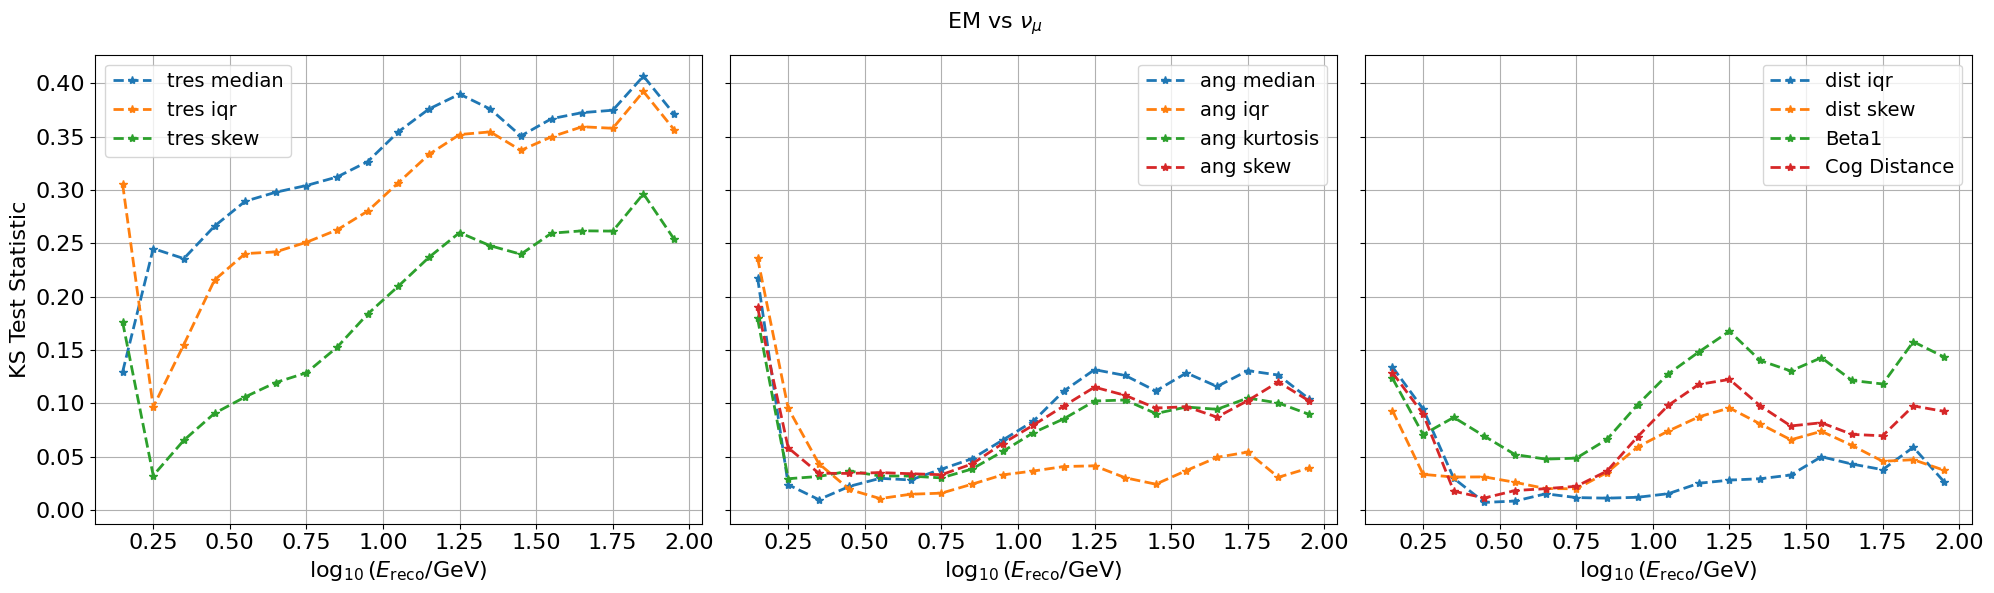

In [8]:
import matplotlib.pyplot as plt

# ---------------- Plot 2: Reco Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].plot(bin_centers_energy['tres_median'], sep_vars_energy['tres_median'], '*--', linewidth=2, label='tres median')
axs[0].plot(bin_centers_energy['tres_iqr'], sep_vars_energy['tres_iqr'], '*--', linewidth=2, label='tres iqr')
axs[0].plot(bin_centers_energy['tres_skew'], sep_vars_energy['tres_skew'], '*--', linewidth=2, label='tres skew')
#axs[0].set_title('OM level features')
axs[0].set_xlabel(r'$\log_{10}(E_{\mathrm{reco}} / \mathrm{GeV})$')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].plot(bin_centers_energy['ang_median'], sep_vars_energy['ang_median'], '*--', linewidth=2, label='ang median')
axs[1].plot(bin_centers_energy['ang_iqr'], sep_vars_energy['ang_iqr'], '*--', linewidth=2, label='ang iqr')
axs[1].plot(bin_centers_energy['ang_kurtosis'], sep_vars_energy['ang_kurtosis'], '*--', linewidth=2, label='ang kurtosis')
axs[1].plot(bin_centers_energy['ang_skew'], sep_vars_energy['ang_skew'], '*--', linewidth=2, label='ang skew')
#axs[1].set_title('Beta Variables')
axs[1].set_xlabel(r'$\log_{10}(E_{\mathrm{reco}} / \mathrm{GeV})$')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].plot(bin_centers_energy['dist_iqr'], sep_vars_energy['dist_iqr'], '*--', linewidth=2, label='dist iqr')
axs[2].plot(bin_centers_energy['dist_skew'], sep_vars_energy['dist_skew'], '*--', linewidth=2, label='dist skew')
axs[2].plot(bin_centers_energy['Beta1Reco'], sep_vars_energy['Beta1Reco'], '*--', linewidth=2, label='Beta1')
axs[2].plot(bin_centers_energy['CogDistance'], sep_vars_energy['CogDistance'], '*--', linewidth=2, label='Cog Distance')
#axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel(r'$\log_{10}(E_{\mathrm{reco}} / \mathrm{GeV})$')
axs[2].legend()
axs[2].grid(True)

#fig.suptitle(r'EM vs Hadronic Shower', fontsize=16)
fig.suptitle(r'EM vs $\nu_\mu$', fontsize=16)
plt.tight_layout()
#plt.show()
plt.savefig('./log10_EM_vs_NuMu_KS_test_statistic.pdf', bbox_inches='tight', dpi=200)

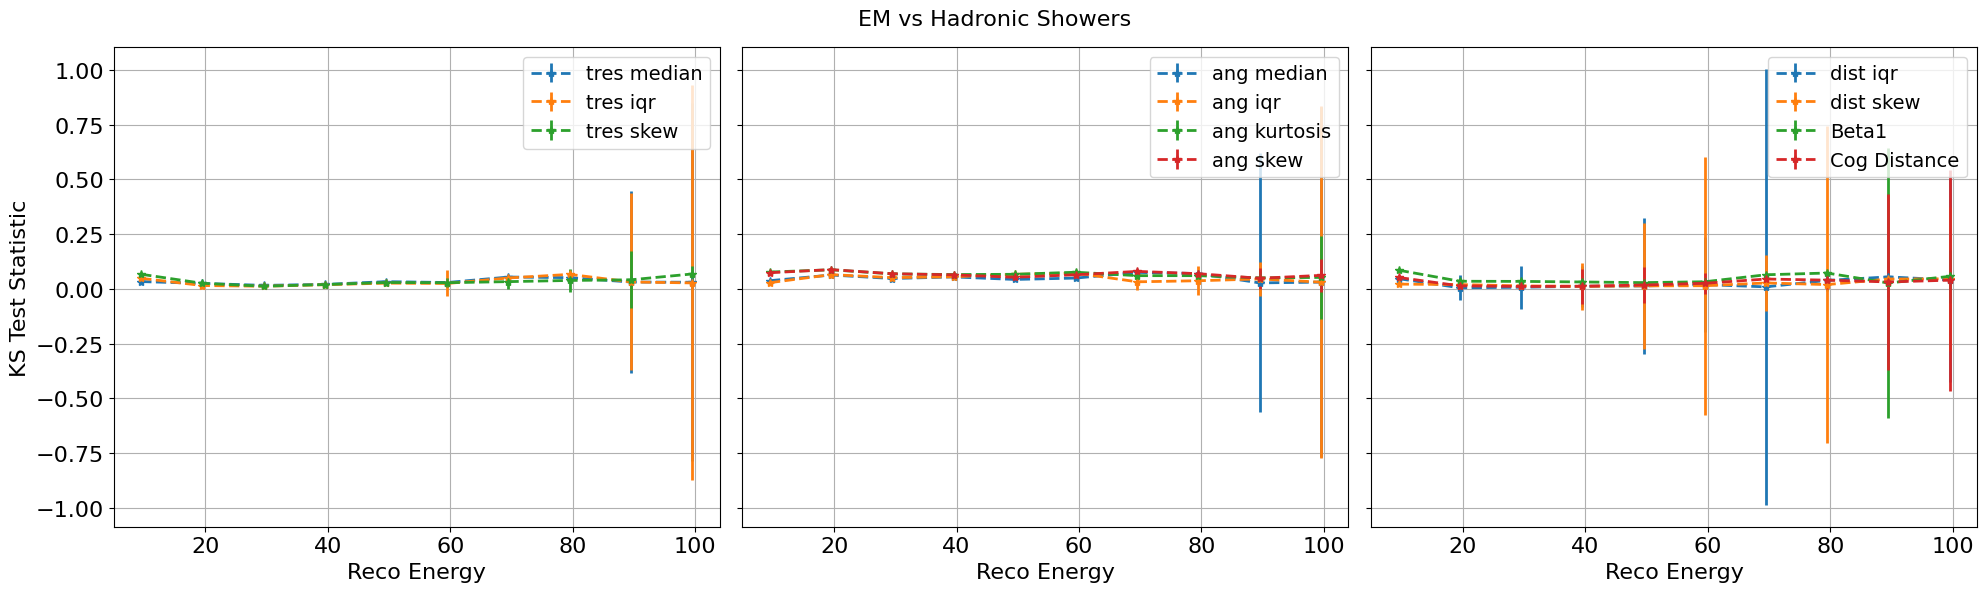

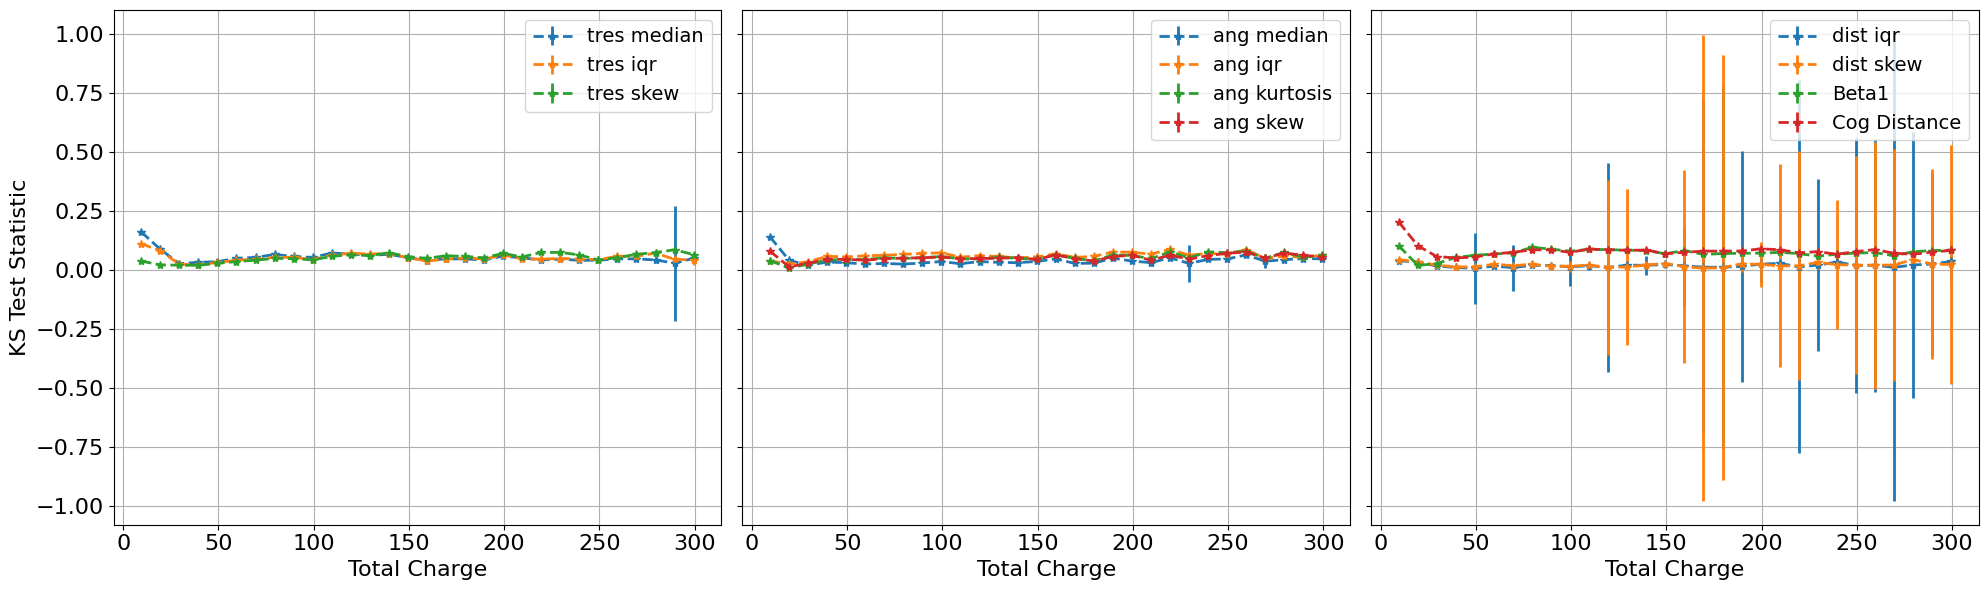

In [11]:
import matplotlib.pyplot as plt

# ---------------- Plot 2: Reco Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].errorbar(bin_centers_energy['tres_median'], sep_vars_energy['tres_median'], yerr=p_vals_energy['tres_median'], fmt='*--', linewidth=2, label='tres median')
axs[0].errorbar(bin_centers_energy['tres_iqr'], sep_vars_energy['tres_iqr'], yerr=p_vals_energy['tres_iqr'], fmt='*--', linewidth=2, label='tres iqr')
axs[0].errorbar(bin_centers_energy['tres_skew'], sep_vars_energy['tres_skew'], yerr=p_vals_energy['tres_skew'], fmt='*--', linewidth=2, label='tres skew')
#axs[0].set_title('OM level features')
axs[0].set_xlabel('Reco Energy')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].errorbar(bin_centers_energy['ang_median'], sep_vars_energy['ang_median'], yerr=p_vals_energy['ang_median'], fmt='*--', linewidth=2, label='ang median')
axs[1].errorbar(bin_centers_energy['ang_iqr'], sep_vars_energy['ang_iqr'], yerr=p_vals_energy['ang_iqr'], fmt='*--', linewidth=2, label='ang iqr')
axs[1].errorbar(bin_centers_energy['ang_kurtosis'], sep_vars_energy['ang_kurtosis'], yerr=p_vals_energy['ang_kurtosis'], fmt='*--', linewidth=2, label='ang kurtosis')
axs[1].errorbar(bin_centers_energy['ang_skew'], sep_vars_energy['ang_skew'], yerr=p_vals_energy['ang_skew'], fmt='*--', linewidth=2, label='ang skew')
#axs[1].set_title('Beta Variables')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].errorbar(bin_centers_energy['dist_iqr'], sep_vars_energy['dist_iqr'], yerr=p_vals_energy['dist_iqr'], fmt='*--', linewidth=2, label='dist iqr')
axs[2].errorbar(bin_centers_energy['dist_skew'], sep_vars_energy['dist_skew'], yerr=p_vals_energy['dist_skew'], fmt='*--', linewidth=2, label='dist skew')
axs[2].errorbar(bin_centers_energy['Beta1Reco'], sep_vars_energy['Beta1Reco'], yerr=p_vals_energy['Beta1Reco'], fmt='*--', linewidth=2, label='Beta1')
axs[2].errorbar(bin_centers_energy['CogDistance'], sep_vars_energy['CogDistance'], yerr=p_vals_energy['CogDistance'], fmt='*--', linewidth=2, label='Cog Distance')
#axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('Reco Energy')
axs[2].legend()
axs[2].grid(True)

fig.suptitle('EM vs Hadronic Showers', fontsize=16)
plt.tight_layout()
#plt.show()
plt.savefig('EM_vs_Hadronic_KS_test_statistic.pdf', bbox_inches='tight', dpi=200)

# ---------------- Plot 4: Total Charge (Reco) ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].errorbar(bin_centers_charge['tres_median'], sep_vars_charge['tres_median'], yerr=p_vals_charge['tres_median'], fmt='*--', linewidth=2, label='tres median')
axs[0].errorbar(bin_centers_charge['tres_iqr'], sep_vars_charge['tres_iqr'], yerr=p_vals_charge['tres_iqr'], fmt='*--', linewidth=2, label='tres iqr')
axs[0].errorbar(bin_centers_charge['tres_skew'], sep_vars_charge['tres_skew'], yerr=p_vals_charge['tres_skew'], fmt='*--', linewidth=2, label='tres skew')
#axs[0].set_title('OM level features')
axs[0].set_xlabel('Total Charge')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].errorbar(bin_centers_charge['ang_median'], sep_vars_charge['ang_median'], yerr=p_vals_charge['ang_median'], fmt='*--', linewidth=2, label='ang median')
axs[1].errorbar(bin_centers_charge['ang_iqr'], sep_vars_charge['ang_iqr'], yerr=p_vals_charge['ang_iqr'], fmt='*--', linewidth=2, label='ang iqr')
axs[1].errorbar(bin_centers_charge['ang_kurtosis'], sep_vars_charge['ang_kurtosis'], yerr=p_vals_charge['ang_kurtosis'], fmt='*--', linewidth=2, label='ang kurtosis')
axs[1].errorbar(bin_centers_charge['ang_skew'], sep_vars_charge['ang_skew'], yerr=p_vals_charge['ang_skew'], fmt='*--', linewidth=2, label='ang skew')
#axs[1].set_title('Beta Variables')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].errorbar(bin_centers_charge['dist_iqr'], sep_vars_charge['dist_iqr'], yerr=p_vals_charge['dist_iqr'], fmt='*--', linewidth=2, label='dist iqr')
axs[2].errorbar(bin_centers_charge['dist_skew'], sep_vars_charge['dist_skew'], yerr=p_vals_charge['dist_skew'], fmt='*--', linewidth=2, label='dist skew')
axs[2].errorbar(bin_centers_charge['Beta1Reco'], sep_vars_charge['Beta1Reco'], yerr=p_vals_charge['Beta1Reco'], fmt='*--', linewidth=2, label='Beta1')
axs[2].errorbar(bin_centers_charge['CogDistance'], sep_vars_charge['CogDistance'], yerr=p_vals_charge['CogDistance'], fmt='*--', linewidth=2, label='Cog Distance')
#axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('Total Charge')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()



In [23]:
sep_var_median_angle, p_val_median_angle, bin_centers_median_angle = get_statistic(df.ang_median[boolCC], df.ang_median[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_iqr_angle, p_val_iqr_angle, bin_centers_iqr_angle = get_statistic(df.ang_iqr[boolCC], df.ang_iqr[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

csep_var_median_angle, cp_val_median_angle, cbin_centers_median_angle = get_statistic(df.ang_median[boolCC], df.ang_median[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_iqr_angle, cp_val_iqr_angle, cbin_centers_iqr_angle = get_statistic(df.ang_iqr[boolCC], df.ang_iqr[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)

In [24]:
sep_var_median_dist, p_val_median_dist, bin_centers_median_dist = get_statistic(df.dist_median[boolCC], df.dist_median[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_iqr_dist, p_val_iqr_dist, bin_centers_iqr_dist = get_statistic(df.dist_iqr[boolCC], df.dist_iqr[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

csep_var_median_dist, cp_val_median_dist, cbin_centers_median_dist = get_statistic(df.dist_median[boolCC], df.dist_median[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_iqr_dist, cp_val_iqr_dist, cbin_centers_iqr_dist = get_statistic(df.dist_iqr[boolCC], df.dist_iqr[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)

In [25]:
sep_var_median_tres, p_val_median_tres, bin_centers_median_tres = get_statistic(df.tres_median[boolCC], df.tres_median[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])
sep_var_iqr_tres, p_val_iqr_tres, bin_centers_iqr_tres = get_statistic(df.tres_iqr[boolCC], df.tres_iqr[boolNC], df.RecoEnergy[boolCC], df.RecoEnergy[boolNC])

csep_var_median_tres, cp_val_median_tres, cbin_centers_median_tres = get_statistic(df.tres_median[boolCC], df.tres_median[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)
csep_var_iqr_tres, cp_val_iqr_tres, cbin_centers_iqr_tres = get_statistic(df.tres_iqr[boolCC], df.tres_iqr[boolNC], df.TotalCharge[boolCC], df.TotalCharge[boolNC], energy=False)

In [26]:
sep_var_beta1_reco, p_val_beta1_reco, bin_centers_beta1_reco = get_statistic(df.Beta1Reco[boolCC], 
                                                                             df.Beta1Reco[boolNC], 
                                                                             df.RecoEnergy[boolCC], 
                                                                             df.RecoEnergy[boolNC])

sep_var_beta2_reco, p_val_beta2_reco, bin_centers_beta2_reco = get_statistic(df.Beta2Reco[boolCC], 
                                                                             df.Beta2Reco[boolNC], 
                                                                             df.RecoEnergy[boolCC], 
                                                                             df.RecoEnergy[boolNC])

sep_var_beta3_reco, p_val_beta3_reco, bin_centers_beta3_reco = get_statistic(df.Beta3Reco[boolCC], 
                                                                             df.Beta3Reco[boolNC], 
                                                                             df.RecoEnergy[boolCC], 
                                                                             df.RecoEnergy[boolNC])

sep_var_beta4_reco, p_val_beta4_reco, bin_centers_beta4_reco = get_statistic(df.Beta4Reco[boolCC], 
                                                                             df.Beta4Reco[boolNC], 
                                                                             df.RecoEnergy[boolCC], 
                                                                             df.RecoEnergy[boolNC])

sep_var_beta5_reco, p_val_beta5_reco, bin_centers_beta5_reco = get_statistic(df.Beta5Reco[boolCC], 
                                                                             df.Beta5Reco[boolNC], 
                                                                             df.RecoEnergy[boolCC], 
                                                                             df.RecoEnergy[boolNC])

csep_var_beta1_reco, cp_val_beta1_reco, cbin_centers_beta1_reco = get_statistic(df.Beta1Reco[boolCC], 
                                                                             df.Beta1Reco[boolNC], 
                                                                             df.TotalCharge[boolCC], 
                                                                             df.TotalCharge[boolNC], energy=False)

csep_var_beta2_reco, cp_val_beta2_reco, cbin_centers_beta2_reco = get_statistic(df.Beta2Reco[boolCC], 
                                                                             df.Beta2Reco[boolNC], 
                                                                             df.TotalCharge[boolCC], 
                                                                             df.TotalCharge[boolNC], energy=False)

csep_var_beta3_reco, cp_val_beta3_reco, cbin_centers_beta3_reco = get_statistic(df.Beta3Reco[boolCC], 
                                                                             df.Beta3Reco[boolNC], 
                                                                             df.TotalCharge[boolCC], 
                                                                             df.TotalCharge[boolNC], energy=False)

csep_var_beta4_reco, cp_val_beta4_reco, cbin_centers_beta4_reco = get_statistic(df.Beta4Reco[boolCC], 
                                                                             df.Beta4Reco[boolNC], 
                                                                             df.TotalCharge[boolCC], 
                                                                             df.TotalCharge[boolNC], energy=False)

csep_var_beta5_reco, cp_val_beta5_reco, cbin_centers_beta5_reco = get_statistic(df.Beta5Reco[boolCC], 
                                                                             df.Beta5Reco[boolNC], 
                                                                             df.TotalCharge[boolCC], 
                                                                             df.TotalCharge[boolNC], energy=False)

In [27]:
reco_cogDistCC = df.CogDistance[boolCC]

reco_cogDistNC = df.CogDistance[boolNC]

sep_var_cog_reco, p_val_cog_reco, bin_centers_cog_reco = get_statistic(reco_cogDistCC, reco_cogDistNC, 
                                                                             df.RecoEnergy[boolCC], 
                                                                             df.RecoEnergy[boolNC])

csep_var_cog_reco, cp_val_cog_reco, cbin_centers_cog_reco = get_statistic(reco_cogDistCC, reco_cogDistNC, 
                                                                             df.TotalCharge[boolCC], 
                                                                             df.TotalCharge[boolNC], energy=False)

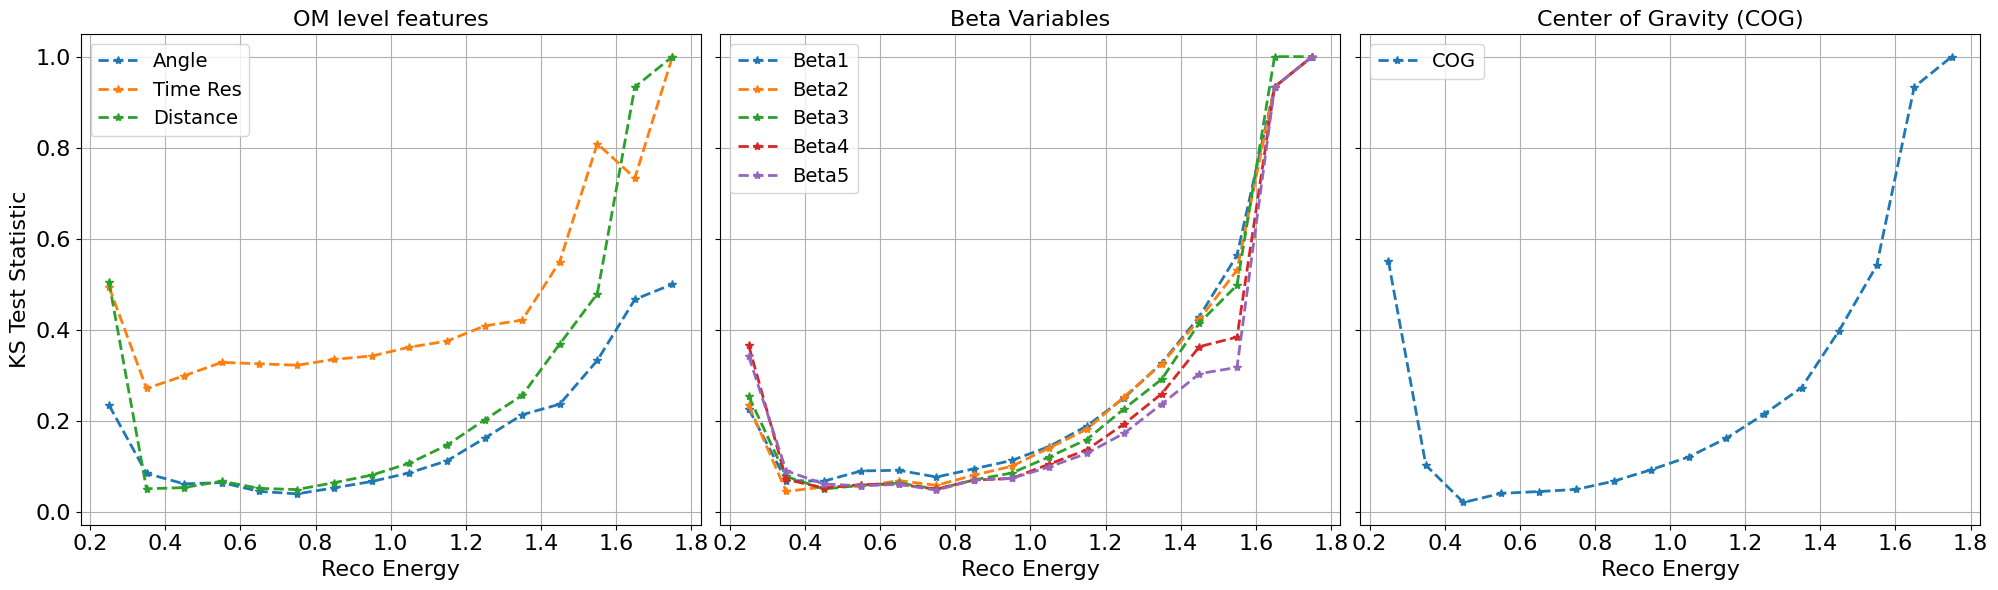

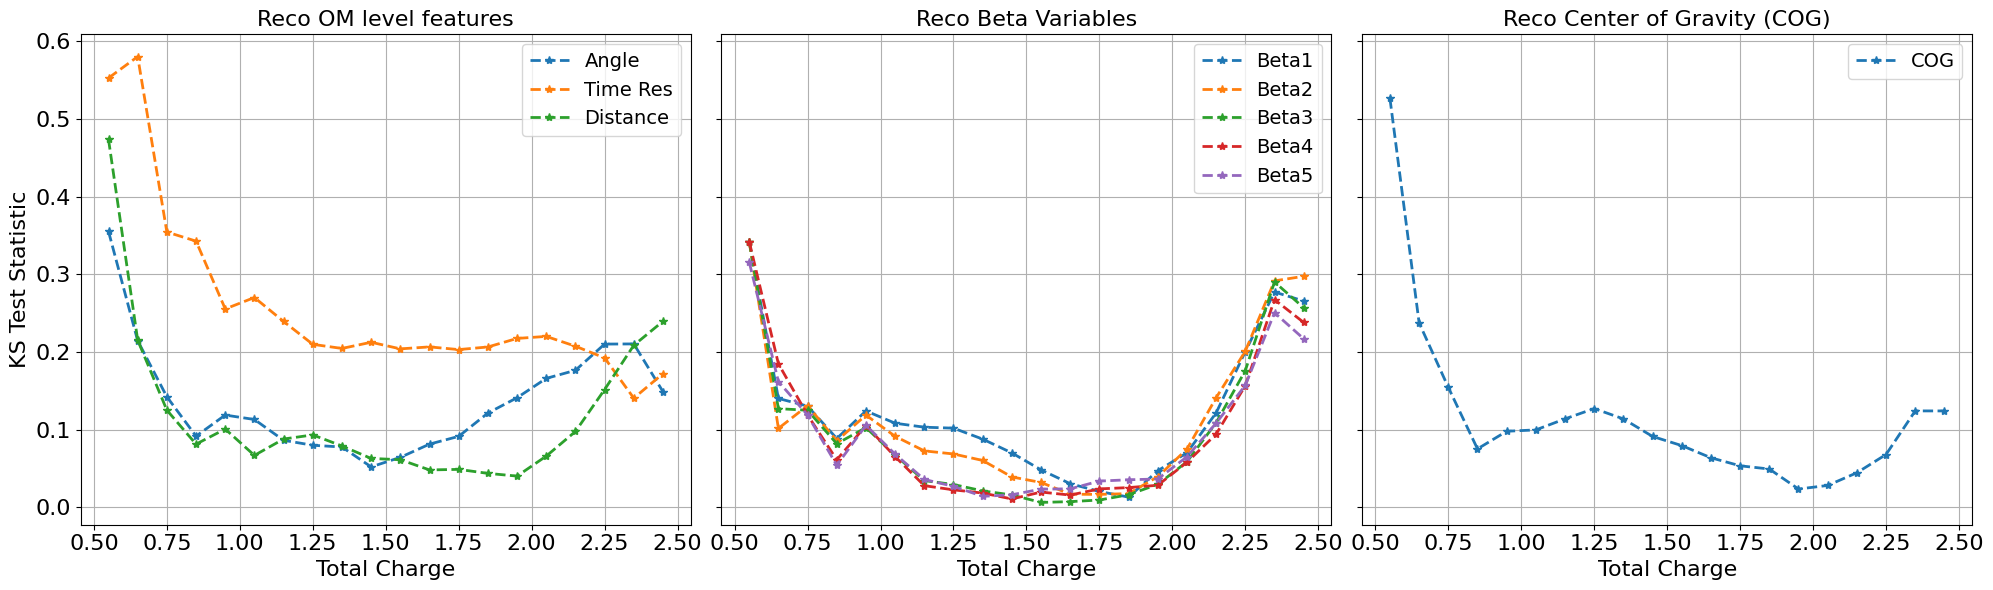

In [28]:
import matplotlib.pyplot as plt

# ---------------- Plot 2: Reco Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].plot(bin_centers_median_angle, sep_var_median_angle, '*--', linewidth=2, label='Angle')
axs[0].plot(bin_centers_median_tres, sep_var_median_tres, '*--', linewidth=2, label='Time Res')
axs[0].plot(bin_centers_median_dist, sep_var_median_dist, '*--', linewidth=2, label='Distance')
axs[0].set_title('OM level features')
axs[0].set_xlabel('Reco Energy')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].plot(bin_centers_beta1_reco, sep_var_beta1_reco, '*--', linewidth=2, label='Beta1')
axs[1].plot(bin_centers_beta2_reco, sep_var_beta2_reco, '*--', linewidth=2, label='Beta2')
axs[1].plot(bin_centers_beta3_reco, sep_var_beta3_reco, '*--', linewidth=2, label='Beta3')
axs[1].plot(bin_centers_beta4_reco, sep_var_beta4_reco, '*--', linewidth=2, label='Beta4')
axs[1].plot(bin_centers_beta5_reco, sep_var_beta5_reco, '*--', linewidth=2, label='Beta5')
axs[1].set_title('Beta Variables')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].plot(bin_centers_cog_reco, sep_var_cog_reco, '*--', linewidth=2, label='COG')
axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('Reco Energy')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ---------------- Plot 4: Total Charge (Reco) ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].plot(cbin_centers_median_angle, csep_var_median_angle, '*--', linewidth=2, label='Angle')
axs[0].plot(cbin_centers_median_tres, csep_var_median_tres, '*--', linewidth=2, label='Time Res')
axs[0].plot(cbin_centers_median_dist, csep_var_median_dist, '*--', linewidth=2, label='Distance')
axs[0].set_title('Reco OM level features')
axs[0].set_xlabel('Total Charge')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].plot(cbin_centers_beta1_reco, csep_var_beta1_reco, '*--', linewidth=2, label='Beta1')
axs[1].plot(cbin_centers_beta2_reco, csep_var_beta2_reco, '*--', linewidth=2, label='Beta2')
axs[1].plot(cbin_centers_beta3_reco, csep_var_beta3_reco, '*--', linewidth=2, label='Beta3')
axs[1].plot(cbin_centers_beta4_reco, csep_var_beta4_reco, '*--', linewidth=2, label='Beta4')
axs[1].plot(cbin_centers_beta5_reco, csep_var_beta5_reco, '*--', linewidth=2, label='Beta5')
axs[1].set_title('Reco Beta Variables')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].plot(cbin_centers_cog_reco, csep_var_cog_reco, '*--', linewidth=2, label='COG')
axs[2].set_title('Reco Center of Gravity (COG)')
axs[2].set_xlabel('Total Charge')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()


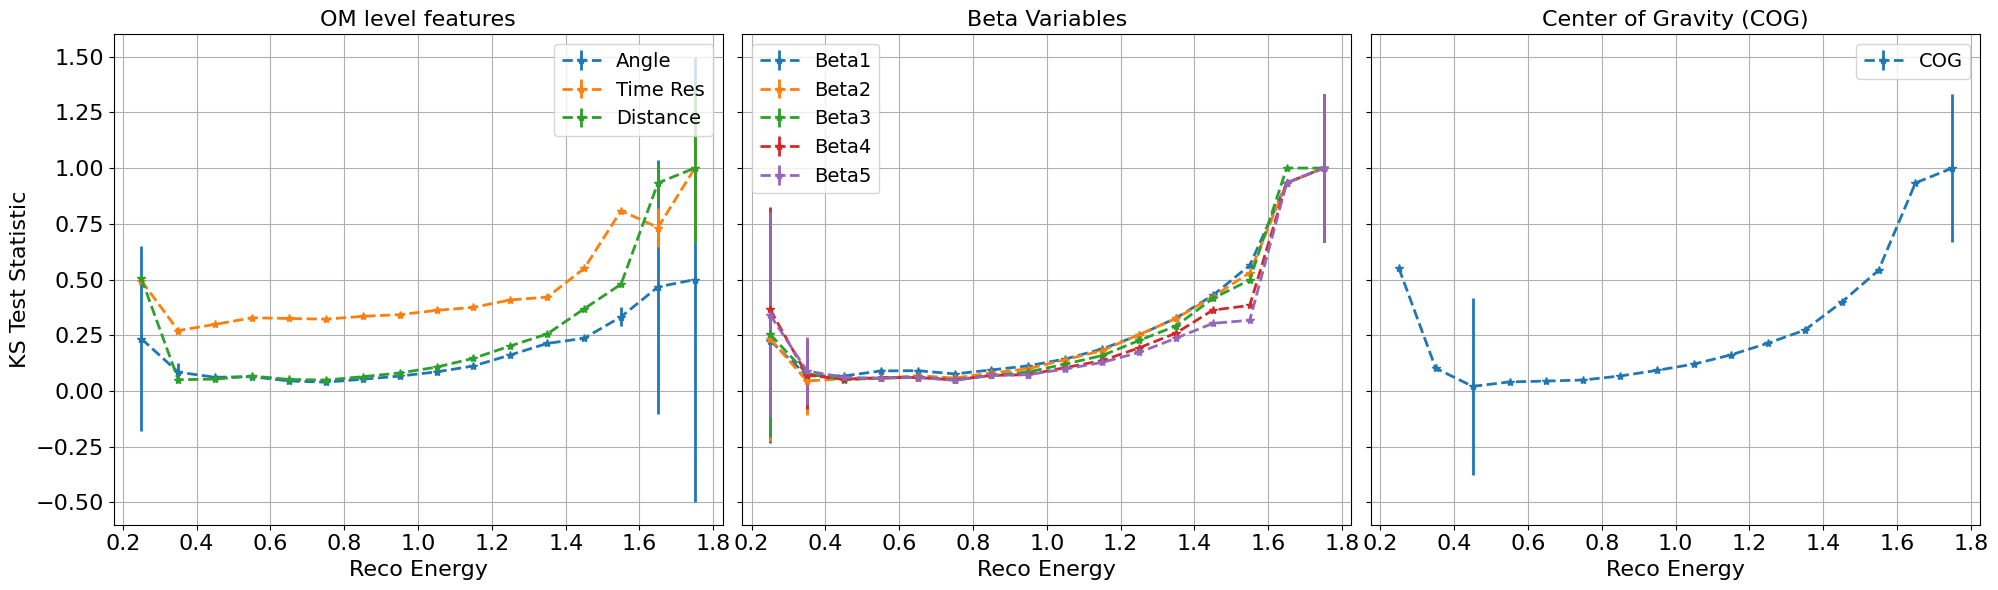

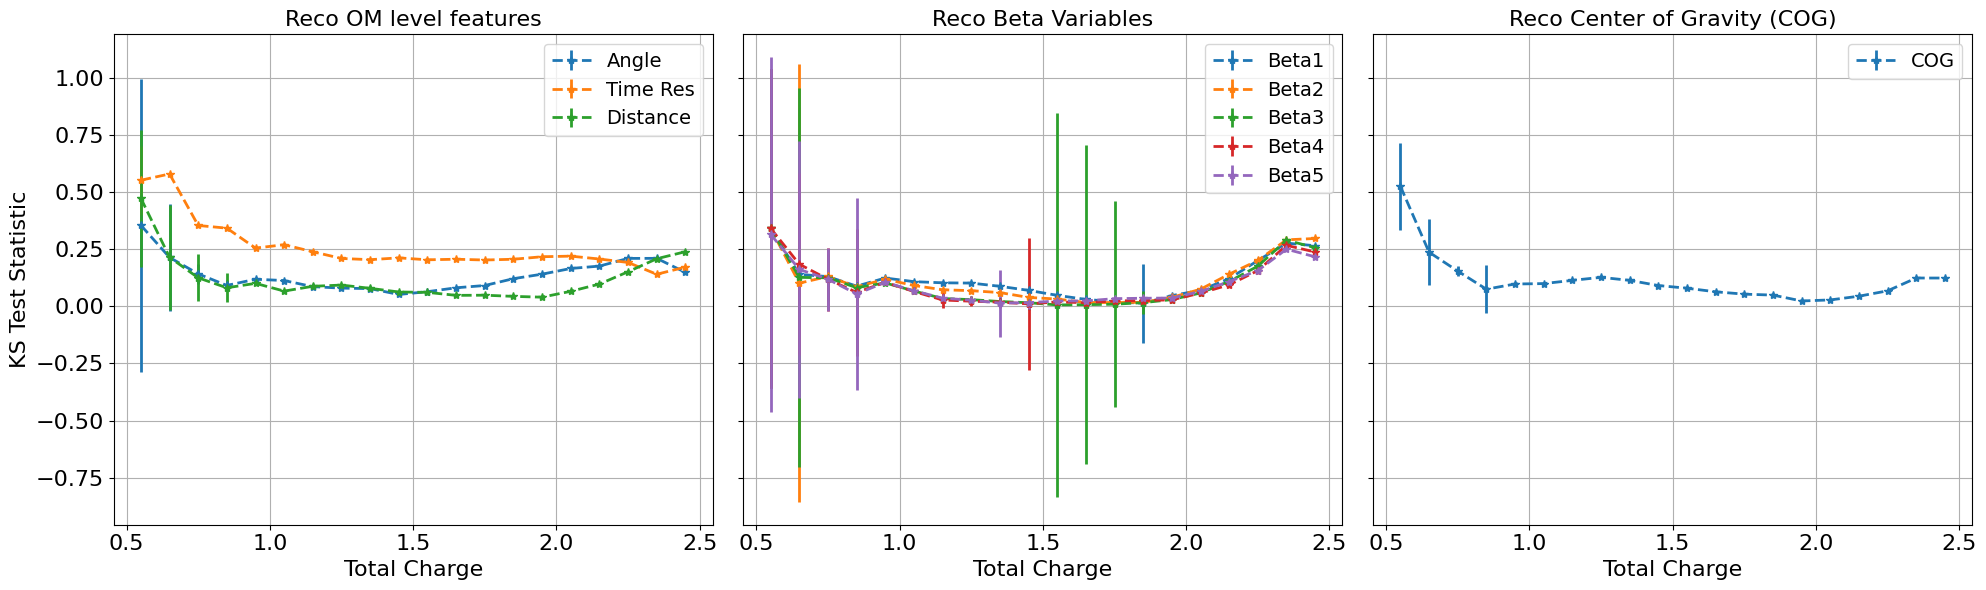

In [29]:
import matplotlib.pyplot as plt

# ---------------- Plot 2: Reco Energy ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].errorbar(bin_centers_median_angle, sep_var_median_angle, yerr=p_val_median_angle, fmt='*--', linewidth=2, label='Angle')
axs[0].errorbar(bin_centers_median_tres, sep_var_median_tres, yerr=p_val_median_tres, fmt='*--', linewidth=2, label='Time Res')
axs[0].errorbar(bin_centers_median_dist, sep_var_median_dist, yerr=p_val_median_tres, fmt='*--', linewidth=2, label='Distance')
axs[0].set_title('OM level features')
axs[0].set_xlabel('Reco Energy')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].errorbar(bin_centers_beta1_reco, sep_var_beta1_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta1')
axs[1].errorbar(bin_centers_beta2_reco, sep_var_beta2_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta2')
axs[1].errorbar(bin_centers_beta3_reco, sep_var_beta3_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta3')
axs[1].errorbar(bin_centers_beta4_reco, sep_var_beta4_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta4')
axs[1].errorbar(bin_centers_beta5_reco, sep_var_beta5_reco, yerr=p_val_beta1_reco, fmt='*--', linewidth=2, label='Beta5')
axs[1].set_title('Beta Variables')
axs[1].set_xlabel('Reco Energy')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].errorbar(bin_centers_cog_reco, sep_var_cog_reco, yerr=p_val_cog_reco, fmt='*--', linewidth=2, label='COG')
axs[2].set_title('Center of Gravity (COG)')
axs[2].set_xlabel('Reco Energy')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# ---------------- Plot 4: Total Charge (Reco) ----------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Geometry
axs[0].errorbar(cbin_centers_median_angle, csep_var_median_angle, yerr=cp_val_median_angle, fmt='*--', linewidth=2, label='Angle')
axs[0].errorbar(cbin_centers_median_tres, csep_var_median_tres, yerr=cp_val_median_tres, fmt='*--', linewidth=2, label='Time Res')
axs[0].errorbar(cbin_centers_median_dist, csep_var_median_dist, yerr=cp_val_median_dist, fmt='*--', linewidth=2, label='Distance')
axs[0].set_title('Reco OM level features')
axs[0].set_xlabel('Total Charge')
axs[0].set_ylabel('KS Test Statistic')
axs[0].legend()
axs[0].grid(True)

# Betas
axs[1].errorbar(cbin_centers_beta1_reco, csep_var_beta1_reco, yerr=cp_val_beta1_reco, fmt='*--', linewidth=2, label='Beta1')
axs[1].errorbar(cbin_centers_beta2_reco, csep_var_beta2_reco, yerr=cp_val_beta2_reco, fmt='*--', linewidth=2, label='Beta2')
axs[1].errorbar(cbin_centers_beta3_reco, csep_var_beta3_reco, yerr=cp_val_beta3_reco, fmt='*--', linewidth=2, label='Beta3')
axs[1].errorbar(cbin_centers_beta4_reco, csep_var_beta4_reco, yerr=cp_val_beta4_reco, fmt='*--', linewidth=2, label='Beta4')
axs[1].errorbar(cbin_centers_beta5_reco, csep_var_beta5_reco, yerr=cp_val_beta5_reco, fmt='*--', linewidth=2, label='Beta5')
axs[1].set_title('Reco Beta Variables')
axs[1].set_xlabel('Total Charge')
axs[1].legend()
axs[1].grid(True)

# COG
axs[2].errorbar(cbin_centers_cog_reco, csep_var_cog_reco, yerr=cp_val_cog_reco, fmt='*--', linewidth=2, label='COG')
axs[2].set_title('Reco Center of Gravity (COG)')
axs[2].set_xlabel('Total Charge')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()